In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("Sentiment-Analysis-on-Tweets").getOrCreate()

In [ ]:
df = spark.read.csv("/content/drive/MyDrive/Colab Notebooks/Pyspark/Datasets/tweets/tweets.csv",header = True,inferSchema=True)

In [ ]:
columns = ["sentiment", "id", "date", "query", "user", "text"]
df = df.toDF(*columns)
df.select("sentiment","text").show(5, truncate=50)

+---------+--------------------------------------------------+
|sentiment|                                              text|
+---------+--------------------------------------------------+
|        0|is upset that he can't update his Facebook by t...|
|        0|@Kenichan I dived many times for the ball. Mana...|
|        0|   my whole body feels itchy and like its on fire |
|        0|@nationwideclass no, it's not behaving at all. ...|
|        0|                     @Kwesidei not the whole crew |
+---------+--------------------------------------------------+
only showing top 5 rows



In [ ]:
print(df.columns)

['sentiment', 'id', 'date', 'query', 'user', 'text']


Preprocess Data

In [ ]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF

In [ ]:
tokenizer = Tokenizer(inputCol="text", outputCol="words")
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
hashingTF = HashingTF(inputCol="filtered", outputCol="rawFeatures", numFeatures=2000)
idf = IDF(inputCol="rawFeatures", outputCol="features")

Encode Labels

In [ ]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="sentiment", outputCol="label")


Training Model using Logistic Regression

In [ ]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="features", labelCol="label")

Build Pipeline

In [ ]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf, indexer, lr])

Train and Evaluate

In [ ]:
train, test = df.randomSplit([0.8, 0.2], seed=42)

# Take a smaller 5% sample of the training data for quicker cross-validation
train_small = train.sample(withReplacement=False, fraction=0.1, seed=42)

print("Full training size:", train.count())
print("Sampled training size:", train_small.count())

model = pipeline.fit(train_small)

predictions = model.transform(test)

from pyspark.ml.evaluation import MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
print("Accuracy:", evaluator.evaluate(predictions))

Full training size: 1280507
Sampled training size: 127695
Accuracy: 0.6921174865098344


Clean the text better

In [ ]:
import pyspark.sql.functions as F

df = df.withColumn(
    "clean_text",
    F.regexp_replace("text", r"http\S+|www\S+|@\w+", "")  # remove URLs & mentions
)
df = df.withColumn("clean_text", F.regexp_replace("clean_text", r"[^a-zA-Z\s]", ""))  # keep only letters
df = df.withColumn("clean_text", F.lower(F.col("clean_text")))  # lowercase
df = df.withColumn("clean_text", F.regexp_replace("clean_text", r"\s+", " "))  # strip extra spaces
df.select("sentiment","clean_text").show(5, truncate=50)
# Split AFTER cleaning
train, test = df.randomSplit([0.8, 0.2], seed=42)

# Take sample for faster training
train_small = train.sample(False, 0.1, seed=42)

# Check columns
print(train_small.columns)


+---------+--------------------------------------------------+
|sentiment|                                        clean_text|
+---------+--------------------------------------------------+
|        0|is upset that he cant update his facebook by te...|
|        0| i dived many times for the ball managed to sav...|
|        0|   my whole body feels itchy and like its on fire |
|        0| no its not behaving at all im mad why am i her...|
|        0|                               not the whole crew |
+---------+--------------------------------------------------+
only showing top 5 rows

['sentiment', 'id', 'date', 'query', 'user', 'text', 'clean_text']


Use N-grams:
Unigrams alone lose context. Adding bi-grams helps catch phrases like “not good”.

In [ ]:
from pyspark.ml.feature import NGram

tokenizer = Tokenizer(inputCol="clean_text", outputCol="words")
ngram = NGram(n=2, inputCol="words", outputCol="bigrams")

Using Naive bayes instead of Logistic Regression

In [ ]:
from pyspark.ml.classification import NaiveBayes
nb = NaiveBayes(labelCol="label", featuresCol="features", modelType="multinomial")

Cross-validation + Hyperparameter tuning

In [ ]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Evaluator
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

# Param grid (tuning HashingTF)
paramGrid = ParamGridBuilder() \
    .addGrid(hashingTF.numFeatures, [5000]) \
    .addGrid(lr.regParam, [0.1]) \
    .addGrid(lr.elasticNetParam, [0.5]) \
    .addGrid(lr.maxIter, [50]) \
    .build()

# --- 3-Fold CV ---
cv3 = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=2
)
cv3_model = cv3.fit(train_small)
acc3 = max(cv3_model.avgMetrics)
print(f"3-Fold CV Accuracy: {acc3:.4f}")

# --- 5-Fold CV ---
cv5 = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=5,
    parallelism=2
)
cv5_model = cv5.fit(train_small)
acc5 = max(cv5_model.avgMetrics)
print(f"5-Fold CV Accuracy: {acc5:.4f}")


3-Fold CV Accuracy: 0.5095
5-Fold CV Accuracy: 0.5086


Random Forest

In [ ]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
import time

# --- Evaluator ---
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
)

# --- Base Model ---
rf = RandomForestClassifier(labelCol="label", featuresCol="features", seed=42)

# --- Param Grid ---
paramGrid = (ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [10, 15])
    .addGrid(rf.featureSubsetStrategy, ["sqrt", "log2"])
    .build())

# ---------- 3-Fold ----------
print("\nRunning 3-Fold Cross Validation...")
start = time.time()

cv3 = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=2
)
cv3_model = cv3.fit(train_small)
cv3_best_acc = max(cv3_model.avgMetrics)
print("3-Fold Best Accuracy:", cv3_best_acc)

# ---------- 5-Fold ----------
print("\nRunning 5-Fold Cross Validation...")
start = time.time()

cv5 = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=5,
    parallelism=2
)
cv5_model = cv5.fit(train_small)
cv5_best_acc = max(cv5_model.avgMetrics)
print("5-Fold Best Accuracy:", cv5_best_acc)


Running 3-Fold Cross Validation...
3-Fold Best Accuracy: 0.7188315055440805

Running 5-Fold Cross Validation...
5-Fold Best Accuracy: 0.7209124464523131


Comparision of accuracies(3-fold CV and 5-fold CV)

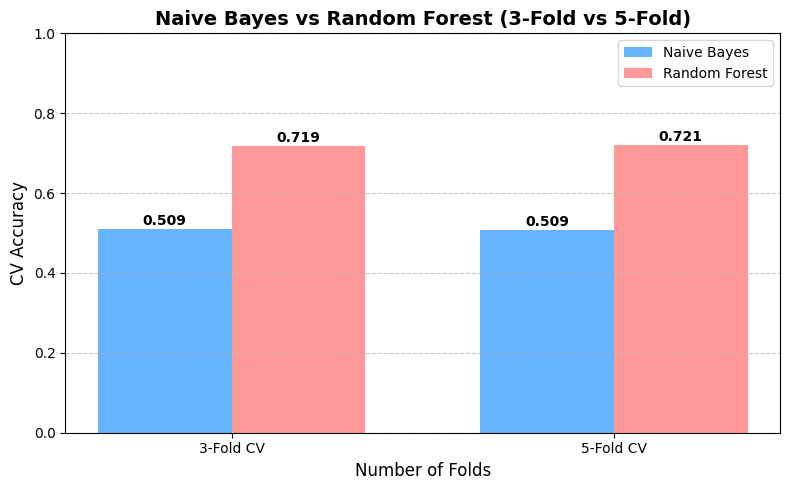

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example results dictionary (replace with your actual values)
results = {
    "NB_3":  0.5095,
    "NB_5": 0.5086,
    "RF_3": 0.7188,
    "RF_5": 0.72091
}

# Data for visualization
folds = ['3-Fold CV', '5-Fold CV']
nb_accuracies = [results["NB_3"], results["NB_5"]]
rf_accuracies = [results["RF_3"], results["RF_5"]]

# Bar positions
x = np.arange(len(folds))
width = 0.35  # width of each bar

# Plot
plt.figure(figsize=(8,5))
plt.bar(x - width/2, nb_accuracies, width, label='Naive Bayes', color='#66b3ff')
plt.bar(x + width/2, rf_accuracies, width, label='Random Forest', color='#ff9999')

# Labels & formatting
plt.title('Naive Bayes vs Random Forest (3-Fold vs 5-Fold)', fontsize=14, fontweight='bold')
plt.ylabel('CV Accuracy', fontsize=12)
plt.xlabel('Number of Folds', fontsize=12)
plt.xticks(x, folds)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

# Value labels above bars
for i in range(len(folds)):
    plt.text(x[i] - width/2, nb_accuracies[i] + 0.01, f"{nb_accuracies[i]:.3f}", ha='center', fontweight='bold')
    plt.text(x[i] + width/2, rf_accuracies[i] + 0.01, f"{rf_accuracies[i]:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


Calculating the F1 Score

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# evaluator for F1
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

f1_score = evaluator.evaluate(predictions)
print("F1 Score:", f1_score)


F1 Score: 0.6920566730526749


In [ ]:
model.save("tweet_sentiment_model")

Testing

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Predict on test set
predictions = model.transform(test)

# Show some predictions
predictions.select("text", "label", "prediction").show(10, truncate=False)

# Evaluate metrics
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

print("Accuracy:", accuracy)
print("F1 Score:", f1)

+------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+
|text                                                                                                                                      |label|prediction|
+------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+
|my whole body feels itchy and like its on fire                                                                                            |0.0  |0.0       |
|@LOLTrish hey  long time no see! Yes.. Rains a bit ,only a bit  LOL , I'm fine thanks , how's you ?                                       |0.0  |1.0       |
|@twittera que me muera ?                                                                                                                  |0.0  |0.0       |
|@smarrison i would've been the first, but i didn't 

Predict sentiment for custom tweets

In [ ]:
from pyspark.sql import Row
label_map = {0.0: "Negative", 1.0: "Positive"}

def predict_sentiment(tweet):
    df = spark.createDataFrame([Row(text=tweet)])
    result = model.transform(df).select("text", "prediction", "probability").collect()

    for r in result:
        sentiment = label_map.get(r["prediction"], "Unknown")
        probs = list(map(float, r["probability"]))
        print(f"Tweet: {r['text']}")
        print(f"Predicted Sentiment: {sentiment} (Negative={probs[0]:.2f}, Positive={probs[1]:.2f})\n")

# Test again
predict_sentiment("I love this phone, it works perfectly!")
predict_sentiment("Worst service ever, totally disappointed.")
predict_sentiment("The product is okay, not too bad.")

Tweet: I love this phone, it works perfectly!
Predicted Sentiment: Negative (Negative=0.51, Positive=0.49)

Tweet: Worst service ever, totally disappointed.
Predicted Sentiment: Negative (Negative=0.67, Positive=0.33)

Tweet: The product is okay, not too bad.
Predicted Sentiment: Positive (Negative=0.36, Positive=0.64)



Comparision

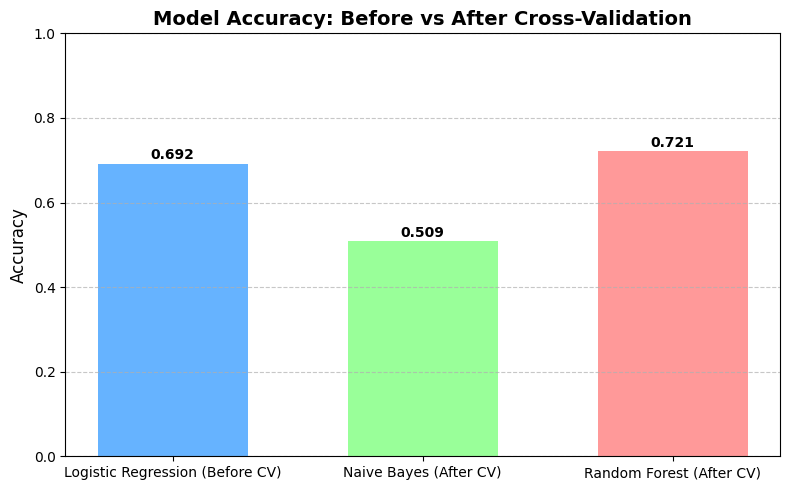

In [ ]:
import matplotlib.pyplot as plt

lr_before_cv = 0.6921  # logistic regression before CV
nb_after_cv  = 0.5095  # best Naive Bayes accuracy after CV
rf_after_cv  = 0.7209   # best Random Forest accuracy after CV

models = ['Logistic Regression (Before CV)', 'Naive Bayes (After CV)', 'Random Forest (After CV)']
accuracies = [lr_before_cv, nb_after_cv, rf_after_cv]
colors = ['#66b3ff', '#99ff99', '#ff9999']

# --- Plot ---
plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=colors, width=0.6)

plt.title('Model Accuracy: Before vs After Cross-Validation', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add accuracy labels above bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()